# Medical Insurance Project

## Importing Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Importation

In [39]:
medical_df = pd.read_csv('../data/insurance.csv')

## Data Overview

In [40]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [41]:
print(f'Rows - {medical_df.shape[0]}\nColumns - {medical_df.shape[1]}')

Rows - 1338
Columns - 7


In [42]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Data Preprocessing

In [43]:
medical_df.isnull().sum().sum()

np.int64(0)

In [44]:
medical_df.duplicated().sum()

np.int64(1)

In [45]:
medical_df = medical_df.drop_duplicates()

## Exploratory Data Analysis

- Distribution of Sex
- Distribution of Children
- Distribution of Region
- Distribution of Smoker
- Distribution of Smoker in Each Region
- Distribution of Smoker By Gender
- Distribution of Total Medical Insurance Cost By Region
- Distribution of Average Medical Cost by Gender

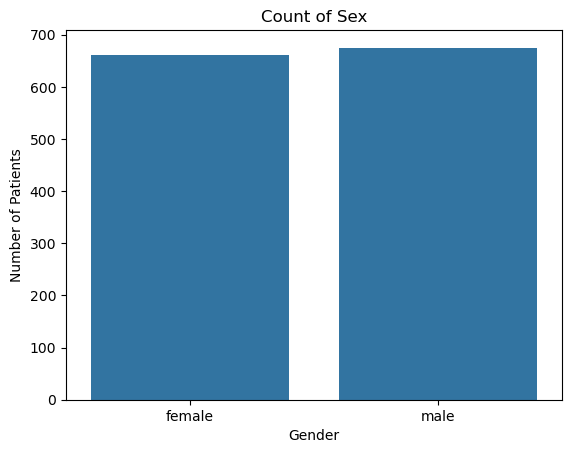

In [46]:
# Distribution of Sex

sns.countplot(x=medical_df['sex'])
plt.title('Count of Sex')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.show()

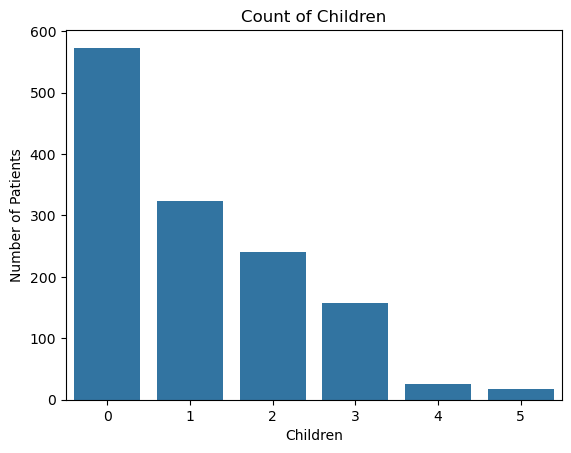

In [47]:
# Distribution of Children

sns.countplot(x=medical_df['children'])
plt.title('Count of Children')
plt.xlabel('Children')
plt.ylabel('Number of Patients')
plt.show()

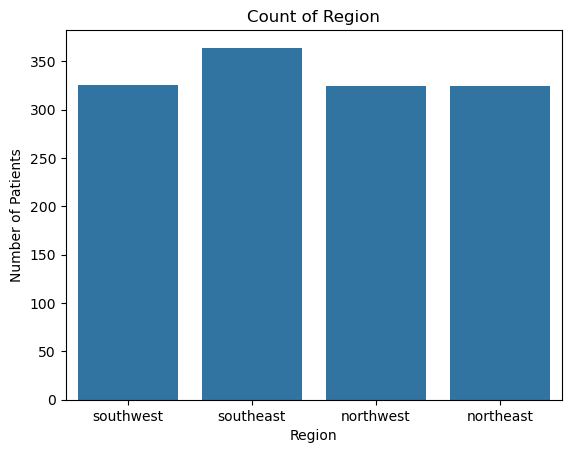

In [48]:
# Distribution of Region

sns.countplot(x=medical_df['region'])
plt.title('Count of Region')
plt.xlabel('Region')
plt.ylabel('Number of Patients')
plt.show()

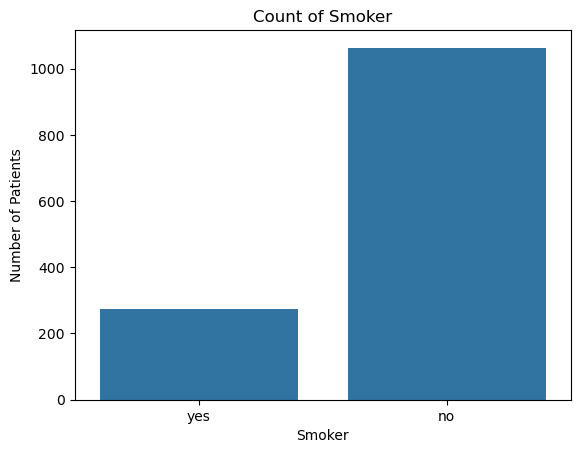

In [49]:
# Distribution of Smoker

sns.countplot(x=medical_df['smoker'])
plt.title('Count of Smoker')
plt.xlabel('Smoker')
plt.ylabel('Number of Patients')
plt.show()

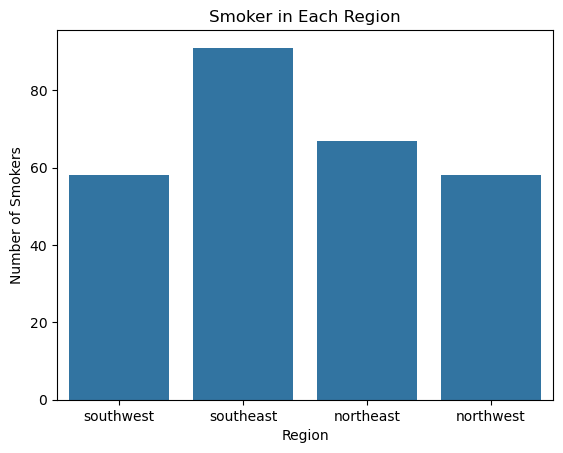

In [50]:
# Distribution of Smokers in Each Region

# Creating Smoker Dataset
smoker_alone = medical_df[medical_df['smoker'] == 'yes']

# Using Smoker Dataset to plot
sns.countplot(x=smoker_alone['region'])
plt.title('Smoker in Each Region')
plt.xlabel('Region')
plt.ylabel('Number of Smokers')
plt.show()

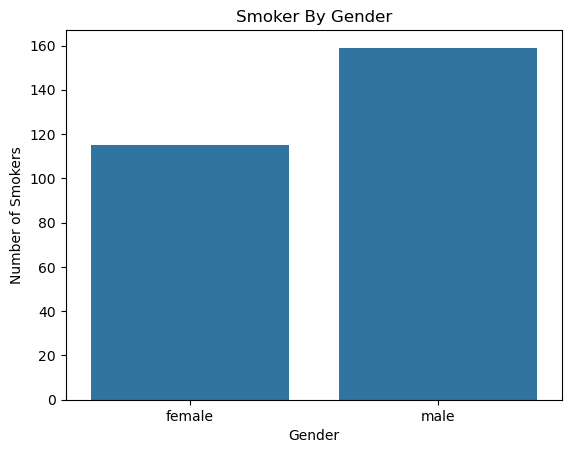

In [51]:
# Distribution of Smoker By Gender

sns.countplot(x=smoker_alone['sex'])
plt.title('Smoker By Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Smokers')
plt.show()

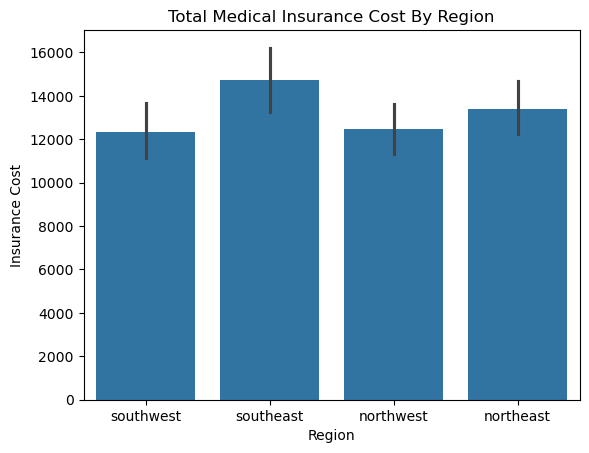

In [52]:
# Distribution of Total Medical Insurance Cost By Region

sns.barplot(x= medical_df['region'], y=medical_df['charges'])
plt.xlabel('Region')
plt.ylabel('Insurance Cost')
plt.title('Total Medical Insurance Cost By Region')
plt.show()

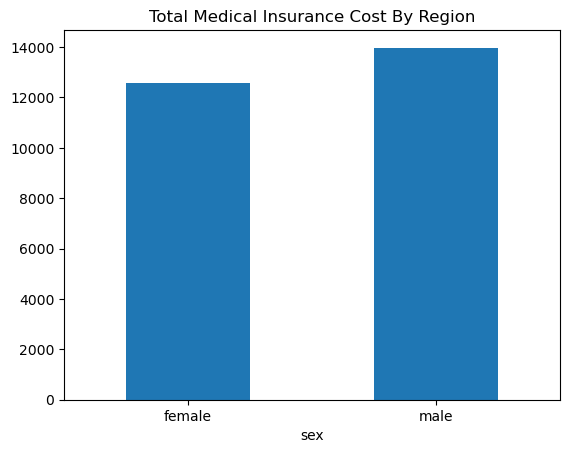

In [53]:
# Distribution of Average Medical Cost by Gender

medical_df.groupby('sex')['charges'].mean().plot(kind = 'bar')
plt.title('Total Medical Insurance Cost By Region')
plt.xticks(rotation = 360)
plt.show()

## Modeling

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [55]:
X = medical_df.drop(columns='charges')
y = medical_df['charges']

In [56]:
numeric_column = X.select_dtypes(include= ['number']).columns.tolist()
categorical_column = X.select_dtypes(include= ['object']).columns.tolist()

In [57]:
# Pipeline for Numeric and Categorical Column
numeric_pipeline = Pipeline(steps=[('numericPipeline', StandardScaler())]) 
categorical_pipeline = Pipeline(steps= [('categoricalPipeline', OneHotEncoder(handle_unknown='ignore'))])

In [58]:
from sklearn.compose import ColumnTransformer

In [59]:
# Preprocessing Pipeline
ml_preprocess = ColumnTransformer(
    transformers= [
        ('TransformNumeric', numeric_pipeline, numeric_column),
        ('TransformCategorical', categorical_pipeline, categorical_column),
    ])

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
# Importing ML Algorithm
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [63]:
lr_model = Pipeline(steps= [('preprocess', ml_preprocess), ('linearModel', LinearRegression())])
dt_model = Pipeline(steps= [('preprocess', ml_preprocess), ('DecisionTree', DecisionTreeRegressor())])
rf_model = Pipeline(steps= [('preprocess', ml_preprocess), ('RandomForest', RandomForestRegressor())])
svm_model = Pipeline(steps= [('preprocess', ml_preprocess), ('SVMModel', SVR())])

### Training The Model

In [64]:
lr_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('linearModel', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
dt_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('DecisionTree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('RandomForest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
svm_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('SVMModel', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Testing The Model

In [68]:
lr_y = lr_model.predict(X_test)
dt_y = dt_model.predict(X_test)
rf_y = rf_model.predict(X_test)
svm_y = svm_model.predict(X_test)

### Performance Evaluation

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [70]:
lr_eval = [mean_absolute_error(y_test, lr_y), mean_squared_error(y_test, lr_y), root_mean_squared_error(y_test, lr_y), r2_score(y_test, lr_y)]
dt_eval = [mean_absolute_error(y_test, dt_y), mean_squared_error(y_test, dt_y), root_mean_squared_error(y_test, dt_y), r2_score(y_test, dt_y)]
rf_eval = [mean_absolute_error(y_test, rf_y), mean_squared_error(y_test, rf_y), root_mean_squared_error(y_test, rf_y), r2_score(y_test, rf_y)]
svm_eval = [mean_absolute_error(y_test, svm_y), mean_squared_error(y_test, svm_y), root_mean_squared_error(y_test, svm_y), r2_score(y_test, svm_y)]

In [71]:
for i in range(4):
    lr_eval[i] = np.round(lr_eval[i], 2)
    dt_eval[i] = np.round(dt_eval[i], 2)
    rf_eval[i] = np.round(rf_eval[i], 2)
    svm_eval[i] = np.round(svm_eval[i], 2)

In [72]:
performance = pd.DataFrame({
    'Models': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM'],
    'MAE': [lr_eval[0], dt_eval[0], rf_eval[0], svm_eval[0]],
    'MSE': [lr_eval[1], dt_eval[1], rf_eval[1], svm_eval[1]],
    'RMSE': [lr_eval[2], dt_eval[2], rf_eval[2], svm_eval[2]],
    'R2-Score': [lr_eval[3], dt_eval[3], rf_eval[3], svm_eval[3]]
})

performance

,Models,MAE,MSE,RMSE,R2-Score
0,Logistic Regression,4177.05,3.547802e+07,5956.34,0.81
1,Decision Tree,2867.54,3.936892e+07,6274.47,0.79
2,Random Forest,2647.06,2.240260e+07,4733.14,0.88
3,SVM,9260.28,2.080903e+08,14425.34,-0.13


### Testing With Unknown Data

In [73]:
sample_data = pd.DataFrame({
    'age':[35],
    'sex':['male'],
    'bmi':[38.2],
    'children':[8],
    'smoker':['yes'],
    'region':['southwest']
})

In [74]:
insurance_prediction = rf_model.predict(sample_data)[0]
print(insurance_prediction)
print(svm_model.predict(sample_data)[0])
print(lr_model.predict(sample_data)[0])
print(dt_model.predict(sample_data)[0])

43181.407701899996
9284.66469021504
36350.280654012924
43753.33705


In [75]:
import joblib

In [77]:
joblib.dump(rf_model, '../models/model.pkl')

['../models/model.pkl']

In [78]:
ml_model = joblib.load('../models/model.pkl')

In [79]:
sample_data = pd.DataFrame({
    'age':[25],
    'sex':['female'],
    'bmi':[39.2],
    'children':[2],
    'smoker':['yes'],
    'region':['northwest']
})

output = ml_model.predict(sample_data)[0]
print(output)

40062.999698300024
